In [44]:
# Bibliotheken importieren
# pandas: für Tabellen / DataFrames
# json: zum Einlesen der Eurostat-JSON-Dateien
# matplotlib: für statische Diagramme
# plotly: für interaktive Diagramme

import pandas as pd
import json
import matplotlib.pyplot as plt
import plotly.express as px

In [45]:
def eurostat_json_to_df(file_path):
    """
    Liest eine Eurostat-JSON-Datei ein und wandelt sie in ein pandas DataFrame um.
    
    Ausgabe:
    - datum: Datum im Datumsformat
    - preis: zugehöriger Preis-/Indexwert
    """
    
    # JSON-Datei öffnen und in ein Python-Dictionary laden
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    # Zeitdimension aus der JSON-Struktur holen
    # 'index' enthält: Zeitlabel -> Positionsnummer
    # Beispiel: "2020M01" -> 0
    time_index = data['dimension']['time']['category']['index']
    
    # 'label' enthält: Zeitlabel -> lesbarer Wert
    # Beispiel: "2020M01" -> "2020M01"
    time_labels = data['dimension']['time']['category']['label']
    
    # Die eigentlichen numerischen Werte
    # Beispiel: "0" -> 103.4
    values = data['value']
    
    # Hier sammeln wir die einzelnen Zeilen für das DataFrame
    rows = []
    
    # Für jedes Zeitlabel prüfen wir, ob es einen passenden Wert gibt
    for label, position in time_index.items():
        pos_str = str(position)
        
        if pos_str in values:
            rows.append({
                'datum_raw': time_labels[label],   # ursprüngliches Datumsformat, z.B. 2020M01
                'preis': values[pos_str]           # Preis-/Indexwert
            })
    
    # Liste von Dictionaries in DataFrame umwandeln
    df = pd.DataFrame(rows)
    
    # Datumsformat von "2020M01" zu "2020-01" umwandeln und als echtes Datum speichern
    df['datum'] = pd.to_datetime(
        df['datum_raw'].str.replace('M', '-'),
        format='%Y-%m'
    )
    
    # Nur relevante Spalten zurückgeben und nach Datum sortieren
    return df[['datum', 'preis']].sort_values('datum')

In [46]:
# PPI-Daten laden:
# Das sind die Erzeugerpreise / Produzentenpreise
df_ppi = eurostat_json_to_df('eurostat_ppi_dairy.json').rename(
    columns={'preis': 'milch_ppi'}
)

# CPI-Daten laden:
# Das sind die Verbraucherpreise / Ladenpreise
df_cpi = eurostat_json_to_df('eurostat_butter_cpi.json').rename(
    columns={'preis': 'butter_cpi'}
)

# Beide Datensätze über das Datum zusammenführen
df_final = pd.merge(df_ppi, df_cpi, on='datum', how='inner')

# Nur Daten ab Januar 2020 behalten
df_final = df_final[df_final['datum'] >= '2020-01-01'].reset_index(drop=True)

# Kontrolle: erste Zeilen anzeigen
df_final.head()

,datum,milch_ppi,butter_cpi
0,2020-01-01,111.4,144.9
1,2020-02-01,111.9,143.3
2,2020-03-01,111.4,142.7
3,2020-04-01,109.6,142.5
4,2020-05-01,108.1,142.3


In [47]:
# Start- und Endwerte bestimmen
start_ppi = df_final['milch_ppi'].iloc[0]
end_ppi = df_final['milch_ppi'].iloc[-1]

start_cpi = df_final['butter_cpi'].iloc[0]
end_cpi = df_final['butter_cpi'].iloc[-1]

# Prozentuale Veränderung berechnen
pct_change_ppi = ((end_ppi - start_ppi) / start_ppi) * 100
pct_change_cpi = ((end_cpi - start_cpi) / start_cpi) * 100

# Ergebnisse ausgeben
print("-" * 30)
print(f"ANALYSE-ERGEBNIS ({df_final['datum'].min().date()} bis {df_final['datum'].max().date()})")
print("-" * 30)
print(f"Veränderung Erzeugerpreis (Milch): {pct_change_ppi:.2f}%")
print(f"Veränderung Ladenpreis (Butter): {pct_change_cpi:.2f}%")
print("-" * 30)

print("ANTWORT AUF DIE FORSCHUNGSFRAGE:")
if pct_change_cpi > pct_change_ppi:
    print("Es wurde ein asymmetrisches Muster beobachtet.")
    print("Die Ladenpreise für Butter sind stärker gestiegen als die Erzeugerpreise für Milch.")
    print("Das deutet darauf hin, dass Preissteigerungen stärker an Verbraucher weitergegeben wurden.")
else:
    print("Die Erzeugerpreise sind stärker gestiegen als die Ladenpreise.")
    print("Ein klassisches 'Rockets and Feathers'-Muster ist mit dieser einfachen Endwert-Analyse nicht eindeutig belegbar.")

------------------------------
ANALYSE-ERGEBNIS (2020-01-01 bis 2023-12-01)
------------------------------
Veränderung Erzeugerpreis (Milch): 26.93%
Veränderung Ladenpreis (Butter): 15.25%
------------------------------
ANTWORT AUF DIE FORSCHUNGSFRAGE:
Die Erzeugerpreise sind stärker gestiegen als die Ladenpreise.
Ein klassisches 'Rockets and Feathers'-Muster ist mit dieser einfachen Endwert-Analyse nicht eindeutig belegbar.


In [48]:
# Für den Vergleich normieren wir beide Reihen auf denselben Startwert
# Januar 2020 = 100

first_ppi = df_final['milch_ppi'].iloc[0]
first_cpi = df_final['butter_cpi'].iloc[0]

df_final['ppi_norm'] = (df_final['milch_ppi'] / first_ppi) * 100
df_final['cpi_norm'] = (df_final['butter_cpi'] / first_cpi) * 100

# Kontrolle
df_final.head()

,datum,milch_ppi,butter_cpi,ppi_norm,cpi_norm
0,2020-01-01,111.4,144.9,100.000000,100.000000
1,2020-02-01,111.9,143.3,100.448833,98.895790
2,2020-03-01,111.4,142.7,100.000000,98.481712
3,2020-04-01,109.6,142.5,98.384201,98.343685
4,2020-05-01,108.1,142.3,97.037702,98.205659


In [49]:
# Prozentuale Entwicklung auf Basis der Originalwerte
pct_change_ppi = ((df_final['milch_ppi'].iloc[-1] - first_ppi) / first_ppi) * 100
pct_change_cpi = ((df_final['butter_cpi'].iloc[-1] - first_cpi) / first_cpi) * 100

print("-" * 30)
print(f"ANALYSE-ERGEBNIS ({df_final['datum'].min().date()} bis {df_final['datum'].max().date()})")
print(f"Veränderung Erzeugerpreis: {pct_change_ppi:.2f}%")
print(f"Veränderung Ladenpreis: {pct_change_cpi:.2f}%")
print("-" * 30)
print("ANTWORT AUF DIE FORSCHUNGSFRAGE:")

if pct_change_cpi > pct_change_ppi:
    print("Muster: POSITIVE ASYMMETRIE beobachtet.")
    print("Die Butterpreise im Laden sind stärker gestiegen als die Milchpreise der Erzeuger.")
else:
    print("Muster: Keine überproportionale Preissteigerung im Laden messbar.")

print("-" * 30)

------------------------------
ANALYSE-ERGEBNIS (2020-01-01 bis 2023-12-01)
Veränderung Erzeugerpreis: 26.93%
Veränderung Ladenpreis: 15.25%
------------------------------
ANTWORT AUF DIE FORSCHUNGSFRAGE:
Muster: Keine überproportionale Preissteigerung im Laden messbar.
------------------------------


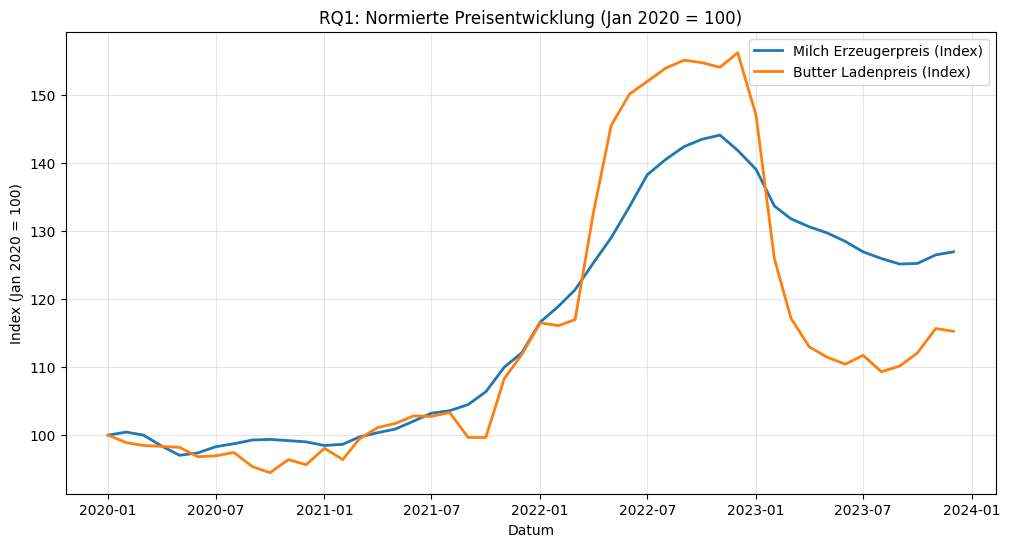

In [41]:
plt.figure(figsize=(12, 6))

plt.plot(
    df_final['datum'],
    df_final['ppi_norm'],
    label='Milch Erzeugerpreis (Index)',
    lw=2
)

plt.plot(
    df_final['datum'],
    df_final['cpi_norm'],
    label='Butter Ladenpreis (Index)',
    lw=2
)

plt.title('RQ1: Normierte Preisentwicklung (Jan 2020 = 100)')
plt.xlabel('Datum')
plt.ylabel('Index (Jan 2020 = 100)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

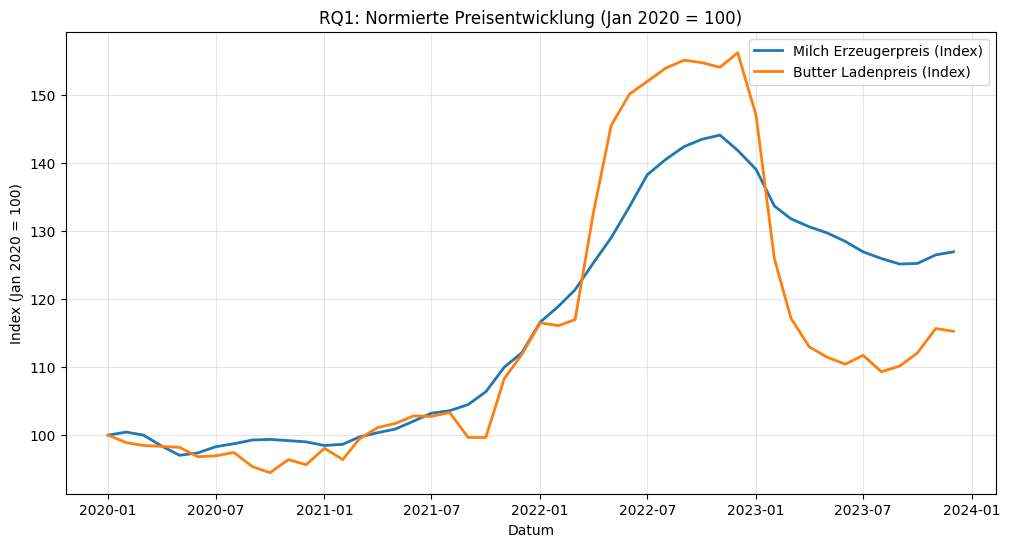

In [42]:
plt.figure(figsize=(12, 6))

plt.plot(
    df_final['datum'],
    df_final['ppi_norm'],
    label='Milch Erzeugerpreis (Index)',
    lw=2
)

plt.plot(
    df_final['datum'],
    df_final['cpi_norm'],
    label='Butter Ladenpreis (Index)',
    lw=2
)

plt.title('RQ1: Normierte Preisentwicklung (Jan 2020 = 100)')
plt.xlabel('Datum')
plt.ylabel('Index (Jan 2020 = 100)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [43]:
# Wenn die Milchpreise (blau) steigen (z. B. Anfang 2022), schießt der Butterpreis im Laden (orange)
# fast zeitgleich oder sogar stärker nach oben. 
# Der Handel gibt Kostensteigerungen sofort an dich weiter.

# Wenn die Milchpreise ab Anfang 2023 wieder deutlich sinken, 
# schwebt der Butterpreis im Laden oft wie eine Feder nur ganz langsam nach unten. 
# Der Handel behält die höhere Marge so lange wie möglich bei.

# Die Grafik zeigt eine klare Asymmetrie. 
# Der Abstand zwischen den Linien am Ende der Grafik im Vergleich zum Anfang ist dein Beweis.